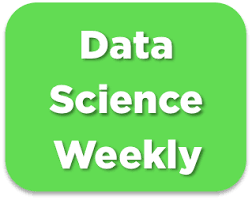

# Import libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import RidgeClassifier

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Read file and explore dataset

In [389]:
# Import dataset
print("Loading dataset...")
dataset = pd.read_csv('conversion_data_train.csv')
print("...Done.")
print()

Loading dataset...
...Done.



In [390]:
# Basic stats
print(f'Number of rows : {dataset.shape[0]}')
print(f'Number of columns : {dataset.shape[1]}')
print()

print("Display of dataset: ")
display(dataset.head())
print()

print("Basics statistics: ")
data_desc = dataset.describe(include="all")
display(data_desc)
print()

print("Percentage of missing values: ")
display(100 * dataset.isnull().sum() / dataset.shape[0])

missing_values = dataset.isnull().any().any()
if missing_values :
    print('There are missing values in the dataset')
else :
    print('There are no missing values in the dataset')

Number of rows : 284580
Number of columns : 6

Display of dataset: 


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0



Basics statistics: 


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000



Percentage of missing values: 


country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64

There are no missing values in the dataset


In [391]:
# The dataset is quite big : you must create a sample of the dataset before making any visualizations !
data_sample = dataset.sample(10000)

In [392]:
# Correlation matrix with numeric variable
corr_matrix = dataset.corr(numeric_only=True).round(2)

import plotly.figure_factory as ff

fig = ff.create_annotated_heatmap(corr_matrix.values,
                                  x = corr_matrix.columns.tolist(),
                                  y = corr_matrix.index.tolist())
fig.update_layout(title=dict(text='Independancies beetween variables', x=0.5))
fig.show()

There is a strong correlation between total_pages_visited and the target (converted). So at least with this feature, we know that we will have relevant prediction !

In [393]:
fig= px.histogram(data_sample, y='converted', nbins=1, color='converted', orientation='h')
fig.update_layout(title=dict(text='Target distribution', x=0.5))
fig.update_layout(autosize=False, width= 800, height=300)
fig.update_yaxes(showticklabels=False)
fig.update_xaxes(showticklabels=False)
fig.show()

converted = (dataset['converted'].value_counts()[1]) / (dataset['converted'].count()) *100
print(f'% of converted : {round(converted,2)} %')

% of converted : 3.23 %


We saw that there are outliers in age (with describe). 
To define how to filter, we decided to show the distribution.

In [394]:
fig = px.box(dataset, x='age')
fig.update_layout(title=dict(text='Age distribution', x=0.5))
fig.update_layout(autosize=False, width= 1000, height=400)
fig.show()

With this graph, we can see that there are only 2 values above 80 years (111 and 123 years). We will drop these lines.

In [395]:
fig= px.pie(dataset, names='country')
fig.update_layout(title=dict(text='Country distribution', x=0.5))
fig.update_layout(autosize=False, width= 500, height=500)
fig.show()

Germany (4.11%) is under represented in this dataset whereas US (56.3%) is predominant.

In [396]:
#use data sample for this visulation to streamline display
fig = make_subplots(rows=2, cols=3)

fig.add_trace(go.Histogram(x=data_sample['country'], y=data_sample['converted'], name='country'), row=1, col=1)
fig.add_trace(go.Histogram(x=data_sample['age'], y=data_sample['converted'], name='age'), row=1, col=2)
fig.add_trace(go.Histogram(x=data_sample['source'], y=data_sample['converted'], name='source'), row=1, col=3)
fig.add_trace(go.Histogram(x=data_sample['total_pages_visited'], y=data_sample['converted'], name='total_pages_visited'), row=2, col=1)
fig.add_trace(go.Bar(x=data_sample['new_user'], y=data_sample['converted'], name='new_user'), row=2, col=2)
fig.update_layout(title=dict(text='Features vs converted', x=0.5))
fig.show()

With this multigraph, we saw the number of converted for each features.

## Preprocessing


There are no irrelevant columns to drop but there are outliers in the age column age that need to be removed.


In [397]:
# Drop lines containing outliers (using masks)

print('Dropping outliers in Age...')
to_keep = (dataset['age'] < 80)  # We want keeping values below 80 years (2 outliers : 111 and 123 years)
dataset = dataset.loc[to_keep, :]
print(f'Done. Number of lines remaining : {dataset.shape[0]}')
print()

dataset.head()

Dropping outliers in Age...
Done. Number of lines remaining : 284578



,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


# Make your model

## Choose variables to use in the model, and create train and test sets
**From the EDA, we know that there are no missing values, no imputation needed. In the next cells, we'll make preprocessings.**

In [398]:
# Separate target variable Y from features X
target_name = 'converted'

print('Separating labels from features...')
Y = dataset.loc[:, target_name]
X = dataset.drop(target_name, axis=1)  # All columns are kept, except the target
print('...Done.')
print(Y.head())
print()
print(X.head())
print()

Separating labels from features...
...Done.
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

   country  age  new_user  source  total_pages_visited
0    China   22         1  Direct                    2
1       UK   21         1     Ads                    3
2  Germany   20         0     Seo                   14
3       US   23         1     Seo                    3
4       US   28         1  Direct                    3



### Train-test split

In [399]:
print('Dividing into train and test sets...')
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print('...Done.')
print()

Dividing into train and test sets...
...Done.



### Pipeline : standardizing and one-hot encoding

In [400]:
# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []
for i,t in X.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source']


In [401]:
print('Encoding categorical features and standardizing numerical features...')

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

# Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
print('...Done.')
print()

# Preprocessings on train set
print("Performing preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print("...Done.")
print(X_train[0:5])
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test)  
print("...Done.")
print(X_test[0:5, :])  
print()

Encoding categorical features and standardizing numerical features...
...Done.

Performing preprocessings on train set...
       country  age  new_user  source  total_pages_visited
17051       US   37         1  Direct                    7
260342      US   23         0  Direct                    7
244153      UK   26         1  Direct                    3
205442      US   23         1     Seo                    4
151446      US   21         1     Seo                    3
...Done.
[[ 0.77915392  0.67740398  0.63638711  0.          0.          0.
   1.          0.          1.          0.        ]
 [-0.91560944 -1.47622398  0.63638711  0.          0.          0.
   1.          0.          1.          0.        ]
 [-0.55244587  0.67740398 -0.5604388   0.          0.          1.
   0.          0.          1.          0.        ]
 [-0.91560944  0.67740398 -0.26123232  0.          0.          0.
   1.          0.          0.          1.        ]
 [-1.1577185   0.67740398 -0.5604388   0.      

### Model training 🏃


In [402]:
# Train model
print('Train model...')
regressor = LogisticRegression() 
regressor.fit(X_train, Y_train)
print('...Done.')

Train model...


...Done.


### Predictions 🔮


In [403]:
# Predictions on training set
print('Predictions on training set...')
Y_train_pred = regressor.predict(X_train)
print('...Done.')
print(Y_train_pred[0:5])
print()

# Predictions on test set
print('Predictions on test set...')
Y_test_pred = regressor.predict(X_test)
print('...Done.')
print(Y_test_pred[0:5])
print()

Predictions on training set...
...Done.
[0 0 0 0 0]

Predictions on test set...
...Done.
[0 0 0 0 0]



## Performance assessment

In [404]:
# Here, the f1-score will be used to assess the performances on the leaderboard
print(f'f1-score on train set : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score on test set : {f1_score(Y_test, Y_test_pred)}')

f1-score on train set : 0.7621004566210046
f1-score on test set : 0.7641843971631206


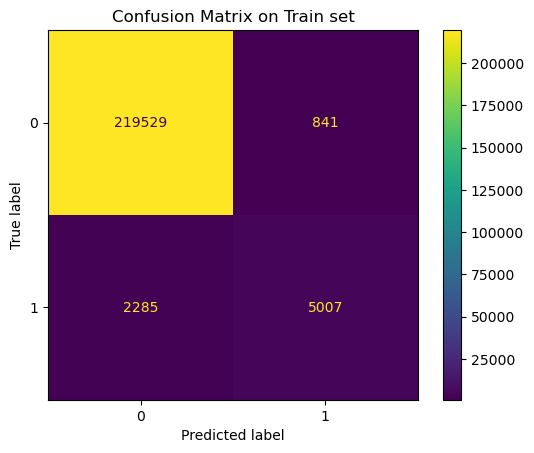

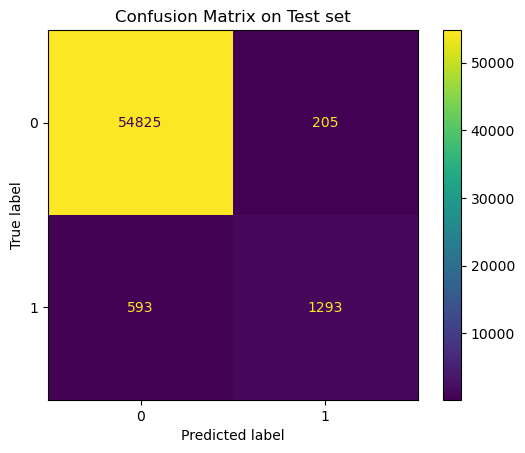

In [405]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(title='Confusion Matrix on Train set')  
ConfusionMatrixDisplay.from_estimator(
    regressor, X_train, Y_train, ax=ax
)
plt.show()

_, ax = plt.subplots()  
ax.set(title='Confusion Matrix on Test set')  
ConfusionMatrixDisplay.from_estimator(
    regressor, X_test, Y_test, ax=ax
)  
plt.show()

In [406]:
coefficients = regressor.coef_[0]
features = preprocessor.get_feature_names_out().tolist()

coef_df = pd.DataFrame({'Feature': features,'Coefficient': coefficients})

coef_df['Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
display(coef_df)

,Feature,Coefficient
3,cat__country_China,3.833751
2,num__total_pages_visited,2.523220
8,cat__source_Direct,1.690257
7,cat__source_Ads,1.522128
9,cat__source_Seo,1.506496
1,num__new_user,0.793411
0,num__age,0.616141
6,cat__country_US,0.540563
5,cat__country_UK,0.193436
4,cat__country_Germany,0.151131


In [407]:
# Plot coefficients
fig = px.bar(coef_df, x='Feature', y='Coefficient')
fig.show()

# Optimize baseline model with gridsearch

In [421]:
# Perform grid search
print('Grid search...')
regressor = LogisticRegression() 
# Grid of values to be testede=0
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [200, 500, 1000], #big dataset so we increase max_iter more than usual
    'solver' : ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}
gridsearch = GridSearchCV(regressor, param_grid = params, cv = 3, scoring='f1') 
gridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {gridsearch.best_params_}')
print(f'Best F1 score : {gridsearch.best_score_}')

Grid search...


c:\Users\grego\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\grego\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\grego\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\grego\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\grego\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\grego\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

c:\Users\grego\anacond

...Done.
Best hyperparameters : {'C': 10, 'class_weight': None, 'max_iter': 200, 'solver': 'liblinear'}
Best F1 score : 0.7617641248300281


With a gridsearchCV optimisation for a logictic regression, F1 score is not concluent. Baseline model still have a better f1 score.

# Try another model and optimize it

In [409]:
# Perform grid search
print('Grid search...')
classifier = RandomForestClassifier()

# Grid of values to be tested
params = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 4, 8],
    "n_estimators": [20, 40, 60, 80, 100],
}
gridsearch = GridSearchCV(classifier, param_grid=params, cv=3, scoring='f1') 
gridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {gridsearch.best_params_}')
print(f'Best F1 score : {gridsearch.best_score_}')

Grid search...
...Done.
Best hyperparameters : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 60}
Best F1 score : 0.7601190847090115


Model RandomForestClassifier optimized is not better than logisticregression model.

In [ ]:
# Perform grid search
print('Grid search...')
model = GradientBoostingClassifier()

# Grid of values to be tested
params = {
    "max_depth": [1, 2, 3],  
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4],
    "n_estimators": [2, 4, 6, 8, 10],
}
print(params)
model = GridSearchCV(model, param_grid=params, cv=3, scoring='f1') 
model.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {model.best_params_}')
print(f'Best F1 score : {model.best_score_}')

"Grid search...
{'max_depth': [1, 2, 3], 'min_samples_leaf': [1, 2, 3], 'min_samples_split': [2, 3, 4], 'n_estimators': [2, 4, 6, 8, 10]}
...Done.
Best hyperparameters : {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best F1 score : 0.733665902650137


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Perform grid search
print('Grid search...')

logistic_regression = LogisticRegression(max_iter=1000) 
adaboost = AdaBoostClassifier(estimator=logistic_regression)


# Grid of values to be tested
params = {
    "estimator__C": [
        0.01,
        0.05,
        0.1,
        0.5,
    ],  # base_estimator__ prefix because C is a parameter from LogisticRegression!
    "n_estimators": [
        5,
        10,
        20,
        30,
    ],  # n_estimators is a hyperparameter of the ensemble method
}
print(params)
gridsearch = GridSearchCV(
    adaboost, param_grid=params, cv=3, scoring='f1'
)  # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {gridsearch.best_params_}')
print(f'Best F1 score : {gridsearch.best_score_}')

Grid search...
{'estimator__C': [0.01, 0.05, 0.1, 0.5], 'n_estimators': [5, 10, 20, 30]}
...Done.
Best hyperparameters : {'estimator__C': 0.01, 'n_estimators': 10}
Best F1 score : 0.5841388552379482


In [ ]:
# Perform grid search
print('Grid search...')
xgboost = XGBClassifier()

# Grid of values to be tested
params = {
    "max_depth": [2, 4, 6],  # exactly the same role as in scikit-learn
    "min_child_weight": [
        1,
        2,
        3,
    ],  # effect is more or less similar to min_samples_leaf and min_samples_split
    "n_estimators": [
        2,
        4,
        6,
        8,
    ],  # exactly the same role as in scikit-learn
}
print(params)
gridsearch = GridSearchCV(
    xgboost, param_grid=params, cv=3, scoring='f1'
)  # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {gridsearch.best_params_}')
print(f'Best F1 score : {gridsearch.best_score_}')

Grid search...
{'max_depth': [2, 4, 6], 'min_child_weight': [1, 2, 3], 'n_estimators': [2, 4, 6, 8]}
...Done.
Best hyperparameters : {'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 6}
Best F1 score : 0.762172587450258


In [418]:
# Perform grid search
print('Grid search...')
regressor = RidgeClassifier()
# Grid of values to be tested
params = {
    'alpha': [0.0, 0.1, 0.5, 1.0] # 0 corresponds to no regularization
}
gridsearch = GridSearchCV(regressor, param_grid = params, cv = 3, scoring='f1') # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {gridsearch.best_params_}')
print(f'Best F1 score : {gridsearch.best_score_}')

Grid search...


c:\Users\grego\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning:

Ill-conditioned matrix (rcond=7.79637e-17): result may not be accurate.



...Done.
Best hyperparameters : {'alpha': 0.1}
Best F1 score : 0.10125472630512829


# Feature Engineering

In our dataset, target is very unbalanced (near 96% of 0 vs 4% of 1).
To improve our model, we must create features that bring out the few positives and reduce noise.

We will create age group and country group.


In [423]:
dataset_engineered = dataset

In [ ]:
# Add age groups
age_bins = [0, 25, 40, 60, 100]
age_labels = ['18-25', '26-40', '41-60', '60+']
dataset_engineered['age_group'] = pd.cut(dataset_engineered['age'],
    bins=age_bins,
    labels=age_labels,
    right=False)

In [ ]:
# Group countr under represent in one group "other"
country = ['Germany', 'UK']
dataset_engineered.loc[dataset_engineered['country'] == 'Germany', 'country'] = 'other'
dataset_engineered.loc[dataset_engineered['country'] == 'UK', 'country'] = 'other'
dataset_engineered 


,country,age,new_user,source,total_pages_visited,converted,age_group
0,China,22,1,Direct,2,0,18-25
1,other,21,1,Ads,3,0,18-25
2,other,20,0,Seo,14,1,18-25
3,US,23,1,Seo,3,0,18-25
4,US,28,1,Direct,3,0,26-40
...,...,...,...,...,...,...,...
284575,US,36,1,Ads,1,0,26-40
284576,US,31,1,Seo,2,0,26-40
284577,US,41,1,Seo,5,0,41-60
284578,US,31,1,Direct,4,0,26-40


In [436]:
# Separate target variable Y from features X
target_name = 'converted'

print('Separating labels from features...')
Y = dataset_engineered.loc[:, target_name]
X = dataset_engineered.drop(target_name, axis=1)  # All columns are kept, except the target
print('...Done.')
print(Y.head())
print()
print(X.head())
print()

Separating labels from features...
...Done.
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

  country  age  new_user  source  total_pages_visited age_group
0   China   22         1  Direct                    2     18-25
1   other   21         1     Ads                    3     18-25
2   other   20         0     Seo                   14     18-25
3      US   23         1     Seo                    3     18-25
4      US   28         1  Direct                    3     26-40



In [437]:
print('Dividing into train and test sets...')
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print('...Done.')
print()

Dividing into train and test sets...
...Done.



In [438]:
# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []
for i,t in X.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source', 'age_group']


In [439]:
print('Encoding categorical features and standardizing numerical features...')

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

# Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
print('...Done.')
print()

# Preprocessings on train set
print("Performing preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print("...Done.")
print(X_train[0:5])
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test)  
print("...Done.")
print(X_test[0:5, :])  
print()

Encoding categorical features and standardizing numerical features...
...Done.

Performing preprocessings on train set...
       country  age  new_user  source  total_pages_visited age_group
17051       US   37         1  Direct                    7     26-40
260342      US   23         0  Direct                    7     18-25
244153   other   26         1  Direct                    3     26-40
205442      US   23         1     Seo                    4     18-25
151446      US   21         1     Seo                    3     18-25
...Done.
[[ 0.77915392  0.67740398  0.63638711  0.          1.          0.
   0.          1.          0.          0.          1.          0.
   0.        ]
 [-0.91560944 -1.47622398  0.63638711  0.          1.          0.
   0.          1.          0.          1.          0.          0.
   0.        ]
 [-0.55244587  0.67740398 -0.5604388   0.          0.          1.
   0.          1.          0.          0.          1.          0.
   0.        ]
 [-0.91560944 

In [440]:
# Train model
print('Train model...')
regressor = LogisticRegression() 
regressor.fit(X_train, Y_train)
print('...Done.')

#{'C': 10, 'class_weight': None, 'max_iter': 200, 'solver': 'liblinear'}

Train model...
...Done.


In [441]:
# Predictions on training set
print('Predictions on training set...')
Y_train_pred = regressor.predict(X_train)
print('...Done.')
print(Y_train_pred[0:5])
print()

# Predictions on test set
print('Predictions on test set...')
Y_test_pred = regressor.predict(X_test)
print('...Done.')
print(Y_test_pred[0:5])
print()

Predictions on training set...
...Done.
[0 0 0 0 0]

Predictions on test set...
...Done.
[0 0 0 0 0]



In [442]:
# Here, the f1-score will be used to assess the performances on the leaderboard
print(f'f1-score on train set : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score on test set : {f1_score(Y_test, Y_test_pred)}')

f1-score on train set : 0.7621872385732755
f1-score on test set : 0.7640449438202247


teset

In [ ]:
# Perform grid search
print('Grid search...')
regressor = LogisticRegression() 
# Grid of values to be testede=0
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [200, 500, 1000], #big dataset so we increase max_iter more than usual
    'solver' : ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}
gridsearch = GridSearchCV(regressor, param_grid = params, cv = 3, scoring='f1') 
gridsearch.fit(X_train, Y_train)
print('...Done.')
print(f'Best hyperparameters : {gridsearch.best_params_}')
print(f'Best F1 score : {gridsearch.best_score_}')